# Тема #5. Численные алгоритмы и научные вычисления, библиотека SciPy

Место SciPy в экосистеме: Надстройка над NumPy (структуры данных) vs. SciPy (алгоритмы).

Философия: SciPy — это инструмент, который пользуется большим признанием в академической среде (противопоставление MATLAB, R).

## Библиотека SciPy

[Главный сайт SciPy](https://scipy.org/)

[Руководство пользователя (User Guide)](https://docs.scipy.org/doc/scipy/tutorial/index.html)

[Руководство по установке](https://scipy.org/install/)

[Исходный код на GitHub](https://github.com/scipy/scipy)

### Оптимизация (Optimization)

Модуль `scipy.optimize` включает в себя методы как для безусловной (unconstrained), так и для условной (constrained) оптимизации, а также средства для подбора кривых и решения задач линейного программирования.

В основе большинства методов лежит функция minimize, которая предоставляет единый интерфейс к различным алгоритмам.

#### Основы работы с `scipy.optimize.minimize`

Основная функция для минимизации скалярной функции одной или нескольких переменных — `scipy.optimize.minimize`. Её ключевые параметры:

- `fun`: целевая функция, которую необходимо минимизировать. Она должна принимать на вход массив `numpy` (`x`) и возвращать скалярное значение .

- `x0`: начальное приближение (массив `numpy`), с которого начинается поиск.

- `method`: строка, определяющая алгоритм оптимизации (например, `'Nelder-Mead'`, `'BFGS'`, `'Powell'`).

- `args`: кортеж с дополнительными фиксированными аргументами, которые передаются в целевую функцию `fun(x, *args)`.

- `jac`: функция, вычисляющая градиент (производную) целевой функции. Если не указана, градиент оценивается численно.

- `bounds`: последовательность пар (min, max) для задания границ каждой переменной.

- `constraints`: список или словарь, описывающий ограничения (равенства или неравенства).

#### Пример 1: Безусловная минимизация (Unconstrained Minimization)

Начнем с классической задачи — минимизации функции Розенброка (Rosenbrock function). Её глобальный минимум находится в точке $(1, 1, ..., 1)$, где значение функции равно $0$.

##### Метод Нелдера-Мида (Nelder-Mead)

Метод Нелдера-Мида — это симплексный метод, который не требует вычисления производных и подходит для простых задач

In [1]:
import numpy as np
from scipy.optimize import minimize

# Определяем функцию Розенброка для N переменных
def rosen(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

# Начальное приближение
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])

# Запускаем минимизацию методом Нелдера-Мида
res = minimize(rosen, x0, method='Nelder-Mead',
               options={'xatol': 1e-8, 'disp': True})

print("Оптимальное решение (Nelder-Mead):", res.x)
print("Значение функции в минимуме:", res.fun)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 339
         Function evaluations: 571
Оптимальное решение (Nelder-Mead): [1. 1. 1. 1. 1.]
Значение функции в минимуме: 4.861153433422115e-17


#### Метод BFGS (Broyden-Fletcher-Goldfarb-Shanno)

Метод BFGS — это более продвинутый метод, градиентный метод. Для его эффективной работы желательно передать функцию, вычисляющую градиент.

In [2]:
# Функция для вычисления градиента функции Розенброка
def rosen_der(x):
    xm = x[1:-1]
    xm_m1 = x[:-2]
    xm_p1 = x[2:]
    der = np.zeros_like(x)
    der[1:-1] = 200*(xm - xm_m1**2) - 400*(xm_p1 - xm**2)*xm - 2*(1 - xm)
    der[0] = -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0])
    der[-1] = 200*(x[-1] - x[-2]**2)
    return der

# Запускаем минимизацию методом BFGS, передавая градиент
res = minimize(rosen, x0, method='BFGS', jac=rosen_der,
               options={'disp': True})

print("\nОптимальное решение (BFGS):", res.x)
print("Значение функции в минимуме:", res.fun)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 25
         Function evaluations: 30
         Gradient evaluations: 30

Оптимальное решение (BFGS): [1.00000004 1.0000001  1.00000021 1.00000044 1.00000092]
Значение функции в минимуме: 4.0130879949972905e-13


BFGS, как правило, требует значительно меньше итераций, чем Nelder-Mead.

#### Пример 2: Условная оптимизация (Constrained Optimization)

##### Пример 0: Простейший пример

Рассмотрим простейшие примеры безусловной оптимизации.

**Минимизировать:**

$$
c^T x = 5x_1 + 4x_2 + 8x_3
$$

**При ограничениях:**

$$
x_1 + x_2 + x_3 = 1,\quad x \ge 0
$$


In [3]:
from scipy.optimize import linprog

c = [5, 4, 8]

A_eq = [[1, 1, 1]]
b_eq = [1]

bounds = [(0, None), (0, None), (0, None)]

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("Оптимальное решение:", res.x)
print("Минимальное значение функции:", res.fun)

Оптимальное решение: [0. 1. 0.]
Минимальное значение функции: 4.0


Теперь рассмотрим другую задачу с ограничениями. Предположим, нужно минимизировать стоимость цилиндрической банки, объем которой должен быть строго равен $355\ \text{см}^3$.

**Целевая функция (стоимость):** $\text{cost}(D, L)$, где $D$ — диаметр, $L$ — длина.

**Ограничение (равенство):** $V = (\pi/4) \cdot D^2 \cdot L = 355$.

Сначала определим целевую функцию и функцию ограничений.

In [4]:
import numpy as np
from scipy.optimize import minimize

V = 355  # объем в см^3
cost_top = 0.025  # стоимость крышки/дна за см^2
cost_side = 0.043  # стоимость боковой поверхности за см^2

# Целевая функция: стоимость банки
def objective(x):
    D, L = x
    radius = D / 2
    top_area = np.pi * radius**2
    side_area = L * np.pi * D
    return (2 * top_area * cost_top) + (side_area * cost_side)

# Функция ограничений
def constraint_volume(x):
    D, L = x
    radius = D / 2
    volume = np.pi * radius**2 * L
    return volume - V  # Возвращаем разницу, которая должна быть равна 0

# Задаем ограничение как словарь
constraint = {'type': 'eq', 'fun': constraint_volume}

# Начальное приближение
x0 = [9.2, 5.3]  # Диаметр и длина

# Решаем задачу условной оптимизации
res = minimize(objective, x0, constraints=constraint)

print("\nРезультат условной оптимизации:")
print("Оптимальный диаметр (D):", res.x[0])
print("Оптимальная длина (L):", res.x[1])
print("Минимальная стоимость (fun):", res.fun)


Результат условной оптимизации:
Оптимальный диаметр (D): 9.195083068889426
Оптимальная длина (L): 5.3459778819088655
Минимальная стоимость (fun): 9.960758701305975


Для задач с ограничениями также существуют специальные классы `LinearConstraint` и `NonlinearConstraint`.

#### Пример 3: Подбор кривой (Curve Fitting)

`scipy.optimize` предоставляет функцию `curve_fit` для подгонки параметров модели под экспериментальные данные. Это частный случай оптимизации методом наименьших квадратов.


Результат подбора кривой:
Истинные параметры: omega=1.5, phi=1.0
Найденные параметры: omega=1.482, phi=1.043


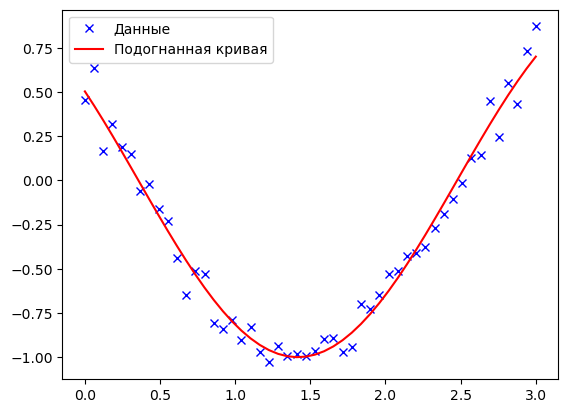

In [5]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Модельная функция: косинус с неизвестными частотой и фазой
def model_func(t, omega, phi):
    return np.cos(omega * t + phi)

# Генерируем "экспериментальные" данные с шумом
xdata = np.linspace(0, 3, 50)
true_params = [1.5, 1.0]
ydata = model_func(xdata, *true_params) + 0.1 * np.random.normal(size=len(xdata))

# Подгоняем модель под данные
popt, pcov = curve_fit(model_func, xdata, ydata, p0=[1, 1])

# popt содержит оптимальные значения параметров
print("\nРезультат подбора кривой:")
print(f"Истинные параметры: omega={true_params[0]}, phi={true_params[1]}")
print(f"Найденные параметры: omega={popt[0]:.3f}, phi={popt[1]:.3f}")

# Визуализация результата
plt.plot(xdata, ydata, 'bx', label='Данные')
plt.plot(xdata, model_func(xdata, *popt), 'r-', label='Подогнанная кривая')
plt.legend()
plt.show()

### Практическая часть

#### Задача 1

Напишите программу, которая решает следующую задачу условной оптимизации.

**Минимизировать:**

$$
c^T x = 5x_1 + 4x_2 + 8x_3
$$

**При ограничениях:**

$$
x_1 + x_2 + x_3 \le 1,\quad x \ge 0
$$

#### Задача 2

Задача: Даны экспериментальные точки $(x, y)$ с шумом (необходимо подготовить входные параметры самостоятельно, взять некоторую функцию, например тригонометрическую и добавить к ней шум).

- С помощью `curve_fit` подобрать модель вида $y=a⋅\exp⁡(−b⋅x)+cy=a⋅\exp(−b⋅x)+c$.

Способы для решения следующих двух пунктов не рассматривались в данном конспекте, но вы можете разобраться в них самостоятельно:

- Вычислить площадь под полученной кривой (интеграл от $0$ до $\max$).

- Используя `solve_ivp`, построить фазовый портрет для подобранной модели (если это дифференциальное уравнение).